(1) 4.9 手寫 QDA 的邏輯，without using sklearn.

In [2]:
import pandas as pd
import numpy as np

train_df = pd.read_csv("https://web.stanford.edu/~hastie/ElemStatLearn/datasets/vowel.train")
test_df = pd.read_csv("https://web.stanford.edu/~hastie/ElemStatLearn/datasets/vowel.test")
X_train = train_df.iloc[:, 2:].values
y_train = train_df['y'].values
X_test = test_df.iloc[:, 2:].values
y_test = test_df['y'].values

classes = np.unique(y_train)
n_features = X_train.shape[1]

param = {}
for k in classes:
    X_k = X_train[y_train == k]
    mu_k = np.mean(X_k, axis=0)
    sigma_k = np.cov(X_k, rowvar=False) 
    pi_k = len(X_k) / len(X_train)
    param[k] = {
        'mu': mu_k,
        'sigma': sigma_k,
        'pi': pi_k,
        'inv_sigma': np.linalg.inv(sigma_k),
        'det_sigma': np.linalg.det(sigma_k) 
    }

# predicing stage: define delta_k(x)
# most critical
# if new input data put into 第k類的高斯分佈中，出現的機率密度（經過對數轉換）是多少？
# 判斷邏輯：它會把資料代入每個類別的公式，算出一個分數。分數越高，代表x越有可能是那個類別。
def f1_pred(x):
    scores = []
    for k in classes:
        p = param[k]
        # QDA 的二次判別公式
        # -0.5 * log|Sigma_k| - 0.5 * (x-mu_k)^T * Sigma_k^-1 * (x-mu_k) + log(pi_k)
        diff = x - p['mu']
        exponent = -0.5 * diff.T @ p['inv_sigma'] @ diff
        log_det = -0.5 * np.log(p['det_sigma'])
        log_pi = np.log(p['pi'])
        
        scores.append(exponent + log_det + log_pi)
    
    return classes[np.argmax(scores)]

# error rate cal
y_pred = [f1_pred(x) for x in X_test]
error_rate = np.mean(y_pred != y_test)

print(f"train_n: {len(X_train)}")
print(f"test_n: {len(X_test)}")
print(f"error rate: {error_rate:.4f}")

train_n: 528
test_n: 462
error rate: 0.5281


(2) EX. 5.5: 語音數據（Phoneme）有 256 個高度相關的特徵，直接跑 QDA 會因為參數過多而導致變異數爆炸。因此，我們必須先用 Natural Cubic Splines 將這 256 維壓縮到較小的空間，再進行分類

- 資料預處理
- 建立自然三次樣條基底矩陣 H
- 交叉驗證（10-fold）：測試 5 種不同的節點數量（例如自由度 df = 4, 8, 12, 16, 20），找出測試錯誤率最低的配置
- 在壓縮後的特徵空間上執行二次判別分析

In [ ]:
import pandas as pd
import numpy as np
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.model_selection import KFold, cross_val_score
from patsy import dmatrix # 用於生成自然樣條基底

url = "https://web.stanford.edu/~hastie/ElemStatLearn/datasets/phoneme.data"
data = pd.read_csv(url)
X = data.iloc[:, 1:257].values  
y = data['g'].values          

frequencies = np.arange(1, 257)

# 5 種不同 df, df 表基底函數的數量，決定平滑程度
df_choices = [4, 8, 12, 16, 20]
results = {}

print(f"{'Degrees of Freedom':<20} | {'10-fold CV Error Rate':<20}")
print("-" * 45)

# CV
kf = KFold(n_splits=10, shuffle=True, random_state=42)

for df in df_choices:
    H = dmatrix(f"cr(x, df={df}) - 1", {"x": frequencies})
    
    # 將原始特徵 X (N x 256) 轉換為過濾後的特徵 X_star (N x df)
    # X_star = X @ H 
    X_star = np.dot(X, H)

    qda = QuadraticDiscriminantAnalysis()
    
    scores = cross_val_score(qda, X_star, y, cv=kf, scoring='accuracy')
    error_rate = 1 - np.mean(scores)
    results[df] = error_rate
    
    print(f"{df:<20} | {error_rate:<20.4f}")

best_df = min(results, key=results.get)
print(f"\n最佳自由度選擇為: df = {best_df}")

(3) Q2. Perform logistic regression and Fisher LDA to the ILPD (Indian Liver Patient
Dataset) and make proper comparisons.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score
from sklearn.preprocessing import StandardScaler

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00225/Indian%20Liver%20Patient%20Dataset%20(ILPD).csv"
column_names = ['Age', 'Gender', 'TB', 'DB', 'Alkphos', 'Sgpt', 'Sgot', 'TP', 'ALB', 'A_G_Ratio', 'Target']
df = pd.read_csv(url, names=column_names)
# data 處理
df['A_G_Ratio'] = df['A_G_Ratio'].fillna(df['A_G_Ratio'].median()) # 處理缺失值 (使用中位數填補)
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})# 轉換類別變數 to 0,1
df['Target'] = df['Target'].map({1: 1, 2: 0})

X = df.drop('Target', axis=1)
y = df['Target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)# 分割訓練集與測試集 (80/20)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# 邏輯迴歸
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)
y_pred_log = log_reg.predict(X_test)
y_prob_log = log_reg.predict_proba(X_test)[:, 1]

# Fisher LDA
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)
y_pred_lda = lda.predict(X_test)
y_prob_lda = lda.predict_proba(X_test)[:, 1]

def evaluate(name, y_true, y_pred, y_prob):
    print(f"\n===== {name} 模型結果 =====")
    acc = accuracy_score(y_true, y_pred)
    error_rate = 1 - acc
    print(f"錯誤率 (Error Rate): {error_rate:.4f}")
    print(f"AUC 分數: {roc_auc_score(y_true, y_prob):.4f}")
    print(classification_report(y_true, y_pred, target_names=['Healthy', 'Patient']))

evaluate("Logistic Regression", y_test, y_pred_log, y_prob_log)
evaluate("Fisher LDA", y_test, y_pred_lda, y_prob_lda)


===== Logistic Regression 模型結果 =====
錯誤率 (Error Rate): 0.2393
AUC 分數: 0.8130
              precision    recall  f1-score   support

     Healthy       0.56      0.30      0.39        30
     Patient       0.79      0.92      0.85        87

    accuracy                           0.76       117
   macro avg       0.68      0.61      0.62       117
weighted avg       0.73      0.76      0.73       117


===== Fisher LDA 模型結果 =====
錯誤率 (Error Rate): 0.2735
AUC 分數: 0.7517
              precision    recall  f1-score   support

     Healthy       0.33      0.07      0.11        30
     Patient       0.75      0.95      0.84        87

    accuracy                           0.73       117
   macro avg       0.54      0.51      0.47       117
weighted avg       0.64      0.73      0.65       117



(4) Q3. 實作 平滑樣條 (Smoothing Splines)，並利用一種特殊的交叉驗證法來尋找最合適的平滑參數 $\lambda$。

平滑樣條公式：$$RSS(f, \lambda) = \sum_{i=1}^N \{y_i - f(x_i)\}^2 + \lambda \int \{f''(t)\}^2 dt$$
- 第一項（數據擬合）：希望曲線離點越近越好。
- 第二項（粗糙度懲罰）：$f''(t)$ 代表曲線的彎曲程度。如果這項很大，代表曲線「抖動」得很厲害。
- 當 $\lambda \to 0$：完全不懲罰抖動，曲線會穿過每個點（插值），變異數極大。
- 當 $\lambda \to \infty$：極度討厭彎曲，最後會逼成一條「直線」。

use Leave-one-subject-out Cross-Validation to choose $\lambda$
- 背景：在骨密度（BMD）這個數據集中，同一個青少年可能有多筆測量紀錄。
- 做法：每次剔除「某一個受試者」（一般的 CV 是隨機刪除資料點，但這裡必須整個人刪除）的所有資料，用剩下的受試者訓練模型，再回來預測被剔除的那個人。
- 目的：確保模型學到的是「人類成長的普遍規律」，而不是死背某幾個特定人的數據。

male 組最佳 s: 0.138950
female 組最佳 s: 0.051795


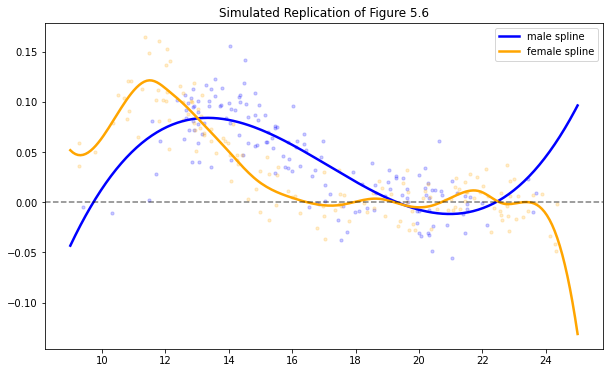


族群平均發育強度(y)比較：
ethnicity
Black    0.039118
White    0.035954
Name: y, dtype: float64


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline
from sklearn.metrics import mean_squared_error

np.random.seed(42) # BMD data 用模擬的

def generate_simulated_bmd(n_subjects=100):
    data = []
    groups = [
        {'sex': 'female', 'eth': 'White', 'peak': 12, 'scale': 0.10},
        {'sex': 'male',   'eth': 'White', 'peak': 14, 'scale': 0.08},
        {'sex': 'female', 'eth': 'Black', 'peak': 11.5, 'scale': 0.13}, # 較早且更高
        {'sex': 'male',   'eth': 'Black', 'peak': 13.5, 'scale': 0.11}
    ]
    
    subj_id = 0
    for g in groups:
        for _ in range(n_subjects // 4):
            subj_id += 1
            base_age = np.random.uniform(9, 22) # 每個受試者在 9~25 歲間隨機有 2~4 個觀測點 (Longitudinal)
            for _ in range(np.random.randint(2, 5)):
                age = base_age + np.random.uniform(0, 3)
                if age > 25: continue
                y_true = g['scale'] * np.exp(-(age - g['peak'])**2 / 6)  # 模擬發育高峰曲線 (Gaussian-like)
                noise = np.random.normal(0, 0.02)
                data.append([subj_id, age, g['sex'], g['eth'], y_true + noise])
                
    return pd.DataFrame(data, columns=['id', 'age', 'sex', 'ethnicity', 'y'])

df = generate_simulated_bmd()

# fn: LOSO-CV 函數
def f1(data, s_space):
    subjects = data['id'].unique()
    best_s = s_space[0]
    min_err = float('inf')
    
    for s in s_space:
        errs = []
        for subj in subjects:
            train = data[data['id'] != subj].sort_values('age')
            test = data[data['id'] == subj]
            if len(train) < 5: continue
            try:
                spl = UnivariateSpline(train['age'], train['y'], s=s)
                errs.append(mean_squared_error(test['y'], spl(test['age'])))
            except: continue
        if errs and np.mean(errs) < min_err:
            min_err = np.mean(errs)
            best_s = s
    return best_s


s_range = np.logspace(-3, 0, 15)
plt.figure(figsize=(10, 6))
for sex, color in [('male', 'blue'), ('female', 'orange')]:
    subset = df[df['sex'] == sex].sort_values('age')
    best_s = f1(subset, s_range)
    print(f"{sex} 組最佳 s: {best_s:.6f}")
    
    final_spl = UnivariateSpline(subset['age'], subset['y'], s=best_s)
    x_grid = np.linspace(9, 25, 200)
    plt.scatter(subset['age'], subset['y'], color=color, alpha=0.2, s=10)
    plt.plot(x_grid, final_spl(x_grid), color=color, lw=2.5, label=f'{sex} spline')

plt.axhline(0, color='black', ls='--', alpha=0.5)
plt.title("Simulated Replication of Figure 5.6")
plt.legend()
plt.show()

print("\n族群平均發育強度(y)比較：")
print(df.groupby('ethnicity')['y'].mean())